In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("merged_file.csv").sort_values(by=["Rok hydrologiczny","Miesiac hydrologiczny","Dzien"])
x1 = pd.read_csv("1982.csv").sort_values(by=["Rok hydrologiczny","Miesiac hydrologiczny","Dzien"])
x2 = pd.read_csv("1983.csv").sort_values(by=["Rok hydrologiczny","Miesiac hydrologiczny","Dzien"])
x3 = pd.read_csv("1984.csv").sort_values(by=["Rok hydrologiczny","Miesiac hydrologiczny","Dzien"])
x4 = pd.read_csv("1984.csv").sort_values(by=["Rok hydrologiczny","Miesiac hydrologiczny","Dzien"])
Q = df["Q [m3/s]"].to_numpy()
Q1 = x1["Q [m3/s]"].to_numpy()
Q2 = x2["Q [m3/s]"].to_numpy()
Q3 = x3["Q [m3/s]"].to_numpy()
Q4 = np.concatenate((x4["Q [m3/s]"].to_numpy(), x3["Q [m3/s]"].to_numpy()))

Q.sort()
Qmin = Q.min()
Qmax = Q.max()

dQ = np.log(Qmax) - np.log(Qmin)

Qb = np.array([Qmin*0.99999, Qmin*np.exp(0.25*dQ), Qmin*np.exp(0.5*dQ), Qmin*np.exp(0.75*dQ), Qmax*1.00001])
diffQ = np.diff(Qb)
ddQ = diffQ/4

L = []
for i,ddq in enumerate(ddQ):
    L.append(np.round(np.arange(Qb[i],Qb[i+1]+0.0001,ddq),3))

Q_bins = np.unique(np.concatenate(L))
Q_bins.sort()
s1 = np.log(Qmax)
s2 = np.log(Qmin)
s3 = Qmin*np.exp(0.75*dQ)
Q1.sort()
Q2.sort()
Q3.sort()
Q4.sort()

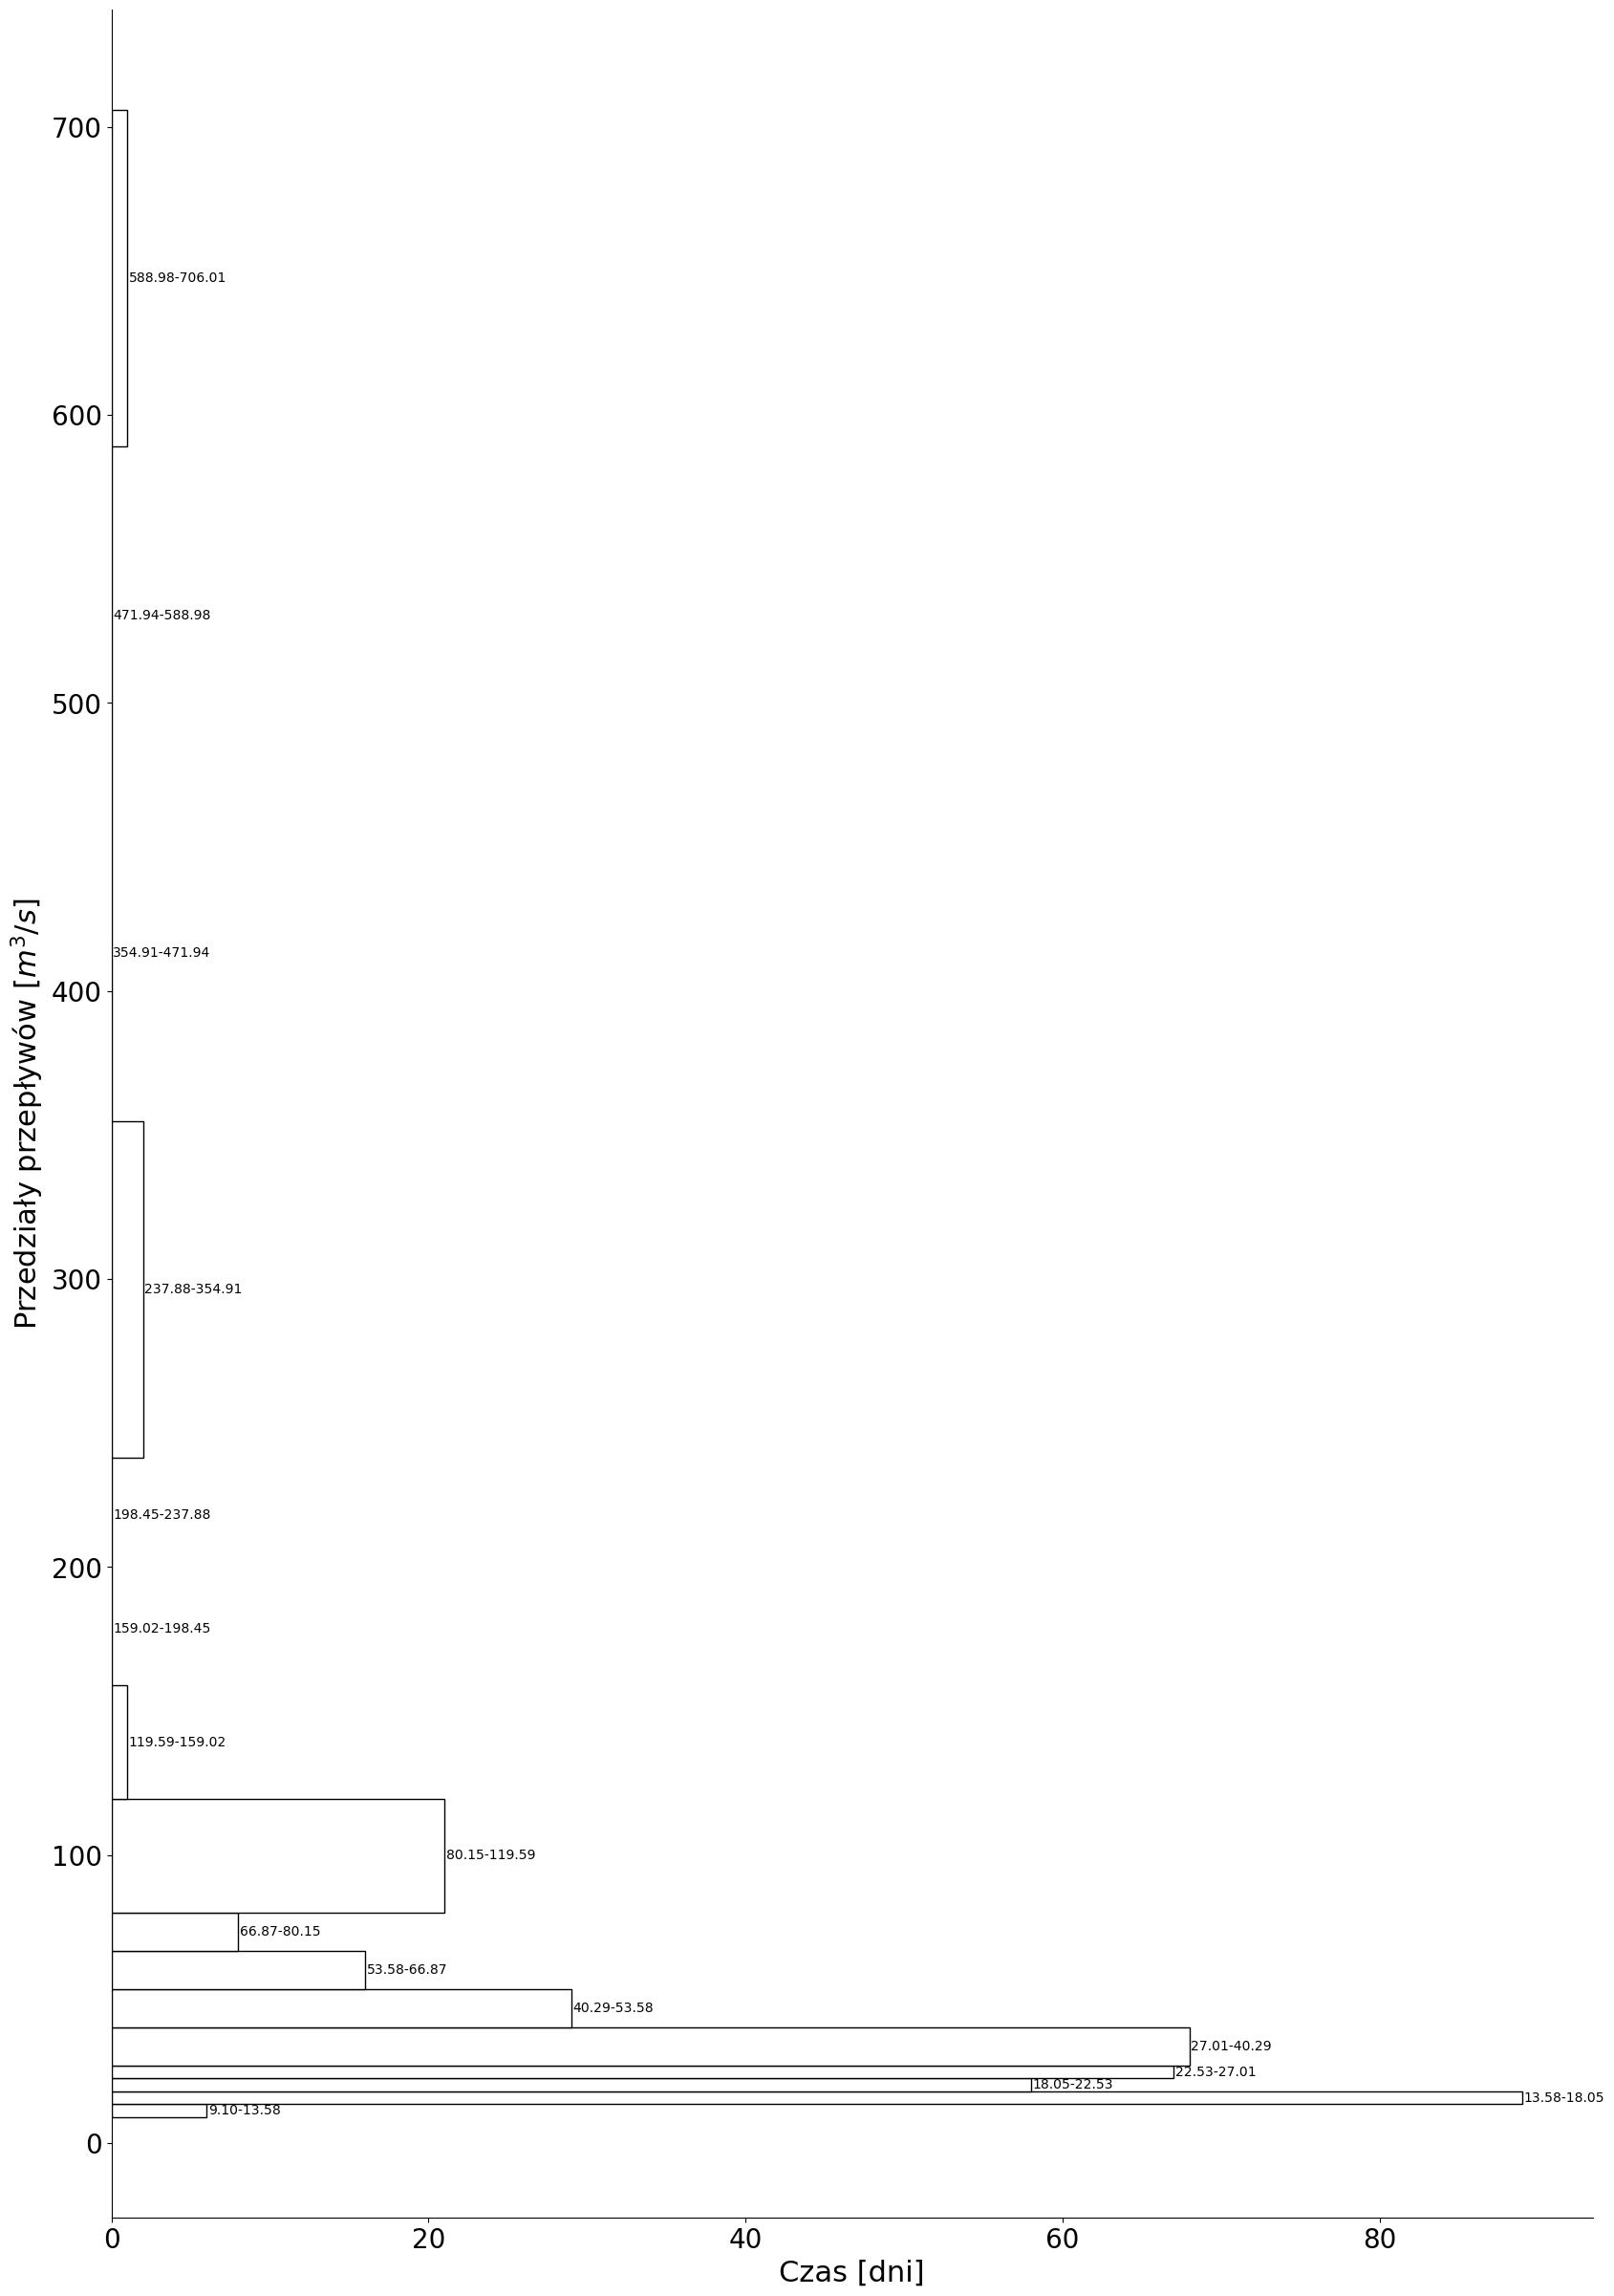

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some random data
# Q = np.random.normal(size=1000)

# Compute the bins
Qmin = Q.min()
Qmax = Q.max()

dQ = np.log(Qmax) - np.log(Qmin)

Qb = np.array([Qmin*0.99999, Qmin*np.exp(0.25*dQ), Qmin*np.exp(0.5*dQ), Qmin*np.exp(0.75*dQ), Qmax*1.00001])
diffQ = np.diff(Qb)
ddQ = diffQ/4

L = []
for i,ddq in enumerate(ddQ):
    L.append(np.round(np.arange(Qb[i],Qb[i+1]+0.0001,ddq),3))

Q_bins = np.unique(np.concatenate(L))
Q_bins.sort()

font = 22
font_ax = font - 2

# Plot the histogram with no edge on the right side
fig, ax = plt.subplots(figsize=(20, 30))
ax.hist(Q3, bins=Q_bins, orientation='horizontal', edgecolor='black', facecolor='white')
ax.set_ylabel('Przedziały przepływów [$m^3/s$]',fontsize=font)
ax.set_xlabel('Czas [dni]',fontsize=font)
ax.tick_params(axis='x', labelsize=font_ax) # increase the x-axis tick label font size
ax.tick_params(axis='y', labelsize=font_ax)

# Remove the right and top spines of the histogram frame
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add labels to the histogram bars
for i in range(len(Q_bins)-1):
    x = ax.patches[i].get_x() + ax.patches[i].get_width() + 0.1
    y = ax.patches[i].get_y() + ax.patches[i].get_height()/2
    label = f"{Q_bins[i]:.2f}-{Q_bins[i+1]:.2f}"
    ax.text(x, y, label, ha='left', va='center')

# Show the plot
plt.show()


In [16]:
df1 = pd.read_csv('rok przeciętny.csv')
df1

,Przedział\nPrzepływów\n[m3/s],Częstość wystąpienia przepływów [dni],Unnamed: 2,Unnamed: 3,Suma\nCzęstości\n[dni],Rok\nPrzeciętny\n[dni],Suma czasów trwania\nPrzepływów wraz z\nWyższymi
0,9.1 - 15.07,0,52,22,74,24.666667,365.333333
1,15.08 - 21.04,32,74,117,223,74.333333,340.666667
2,21.05 - 27.01,26,37,92,155,51.666667,266.333333
3,27.02 - 44.72,54,52,72,178,59.333333,214.666667
4,44.73 - 62.44,87,34,28,149,49.666667,155.333333
5,62.45 - 80.15,104,37,11,152,50.666667,105.666667
6,80.16 - 132.73,46,56,21,123,41.000000,55.000000
7,132.74 - 185.31,10,19,0,29,9.666667,14.000000
8,185.32 - 237.88,2,1,0,3,1.000000,4.333333
9,237.89 - 393.92,4,1,2,7,2.333333,3.333333


In [32]:
Q4

array([ 11.5,  11.5,  12. ,  12. ,  12.6,  12.6,  12.8,  12.8,  13. ,
        13. ,  13.2,  13.2,  13.8,  13.8,  13.8,  13.8,  14.2,  14.2,
        14.2,  14.2,  14.2,  14.2,  14.2,  14.2,  14.3,  14.3,  14.4,
        14.4,  14.5,  14.5,  14.5,  14.5,  14.5,  14.5,  14.5,  14.5,
        14.7,  14.7,  14.7,  14.7,  14.8,  14.8,  14.8,  14.8,  14.8,
        14.8,  14.8,  14.8,  15.1,  15.1,  15.1,  15.1,  15.1,  15.1,
        15.1,  15.1,  15.2,  15.2,  15.6,  15.6,  15.6,  15.6,  15.7,
        15.7,  15.7,  15.7,  15.7,  15.7,  15.7,  15.7,  15.7,  15.7,
        15.7,  15.7,  15.8,  15.8,  15.8,  15.8,  16. ,  16. ,  16.1,
        16.1,  16.2,  16.2,  16.2,  16.2,  16.2,  16.2,  16.3,  16.3,
        16.3,  16.3,  16.4,  16.4,  16.5,  16.5,  16.5,  16.5,  16.5,
        16.5,  16.5,  16.5,  16.5,  16.5,  16.5,  16.5,  16.5,  16.5,
        16.5,  16.5,  16.5,  16.5,  16.5,  16.5,  16.5,  16.5,  16.6,
        16.6,  16.6,  16.6,  16.7,  16.7,  16.7,  16.7,  16.8,  16.8,
        17. ,  17. ,

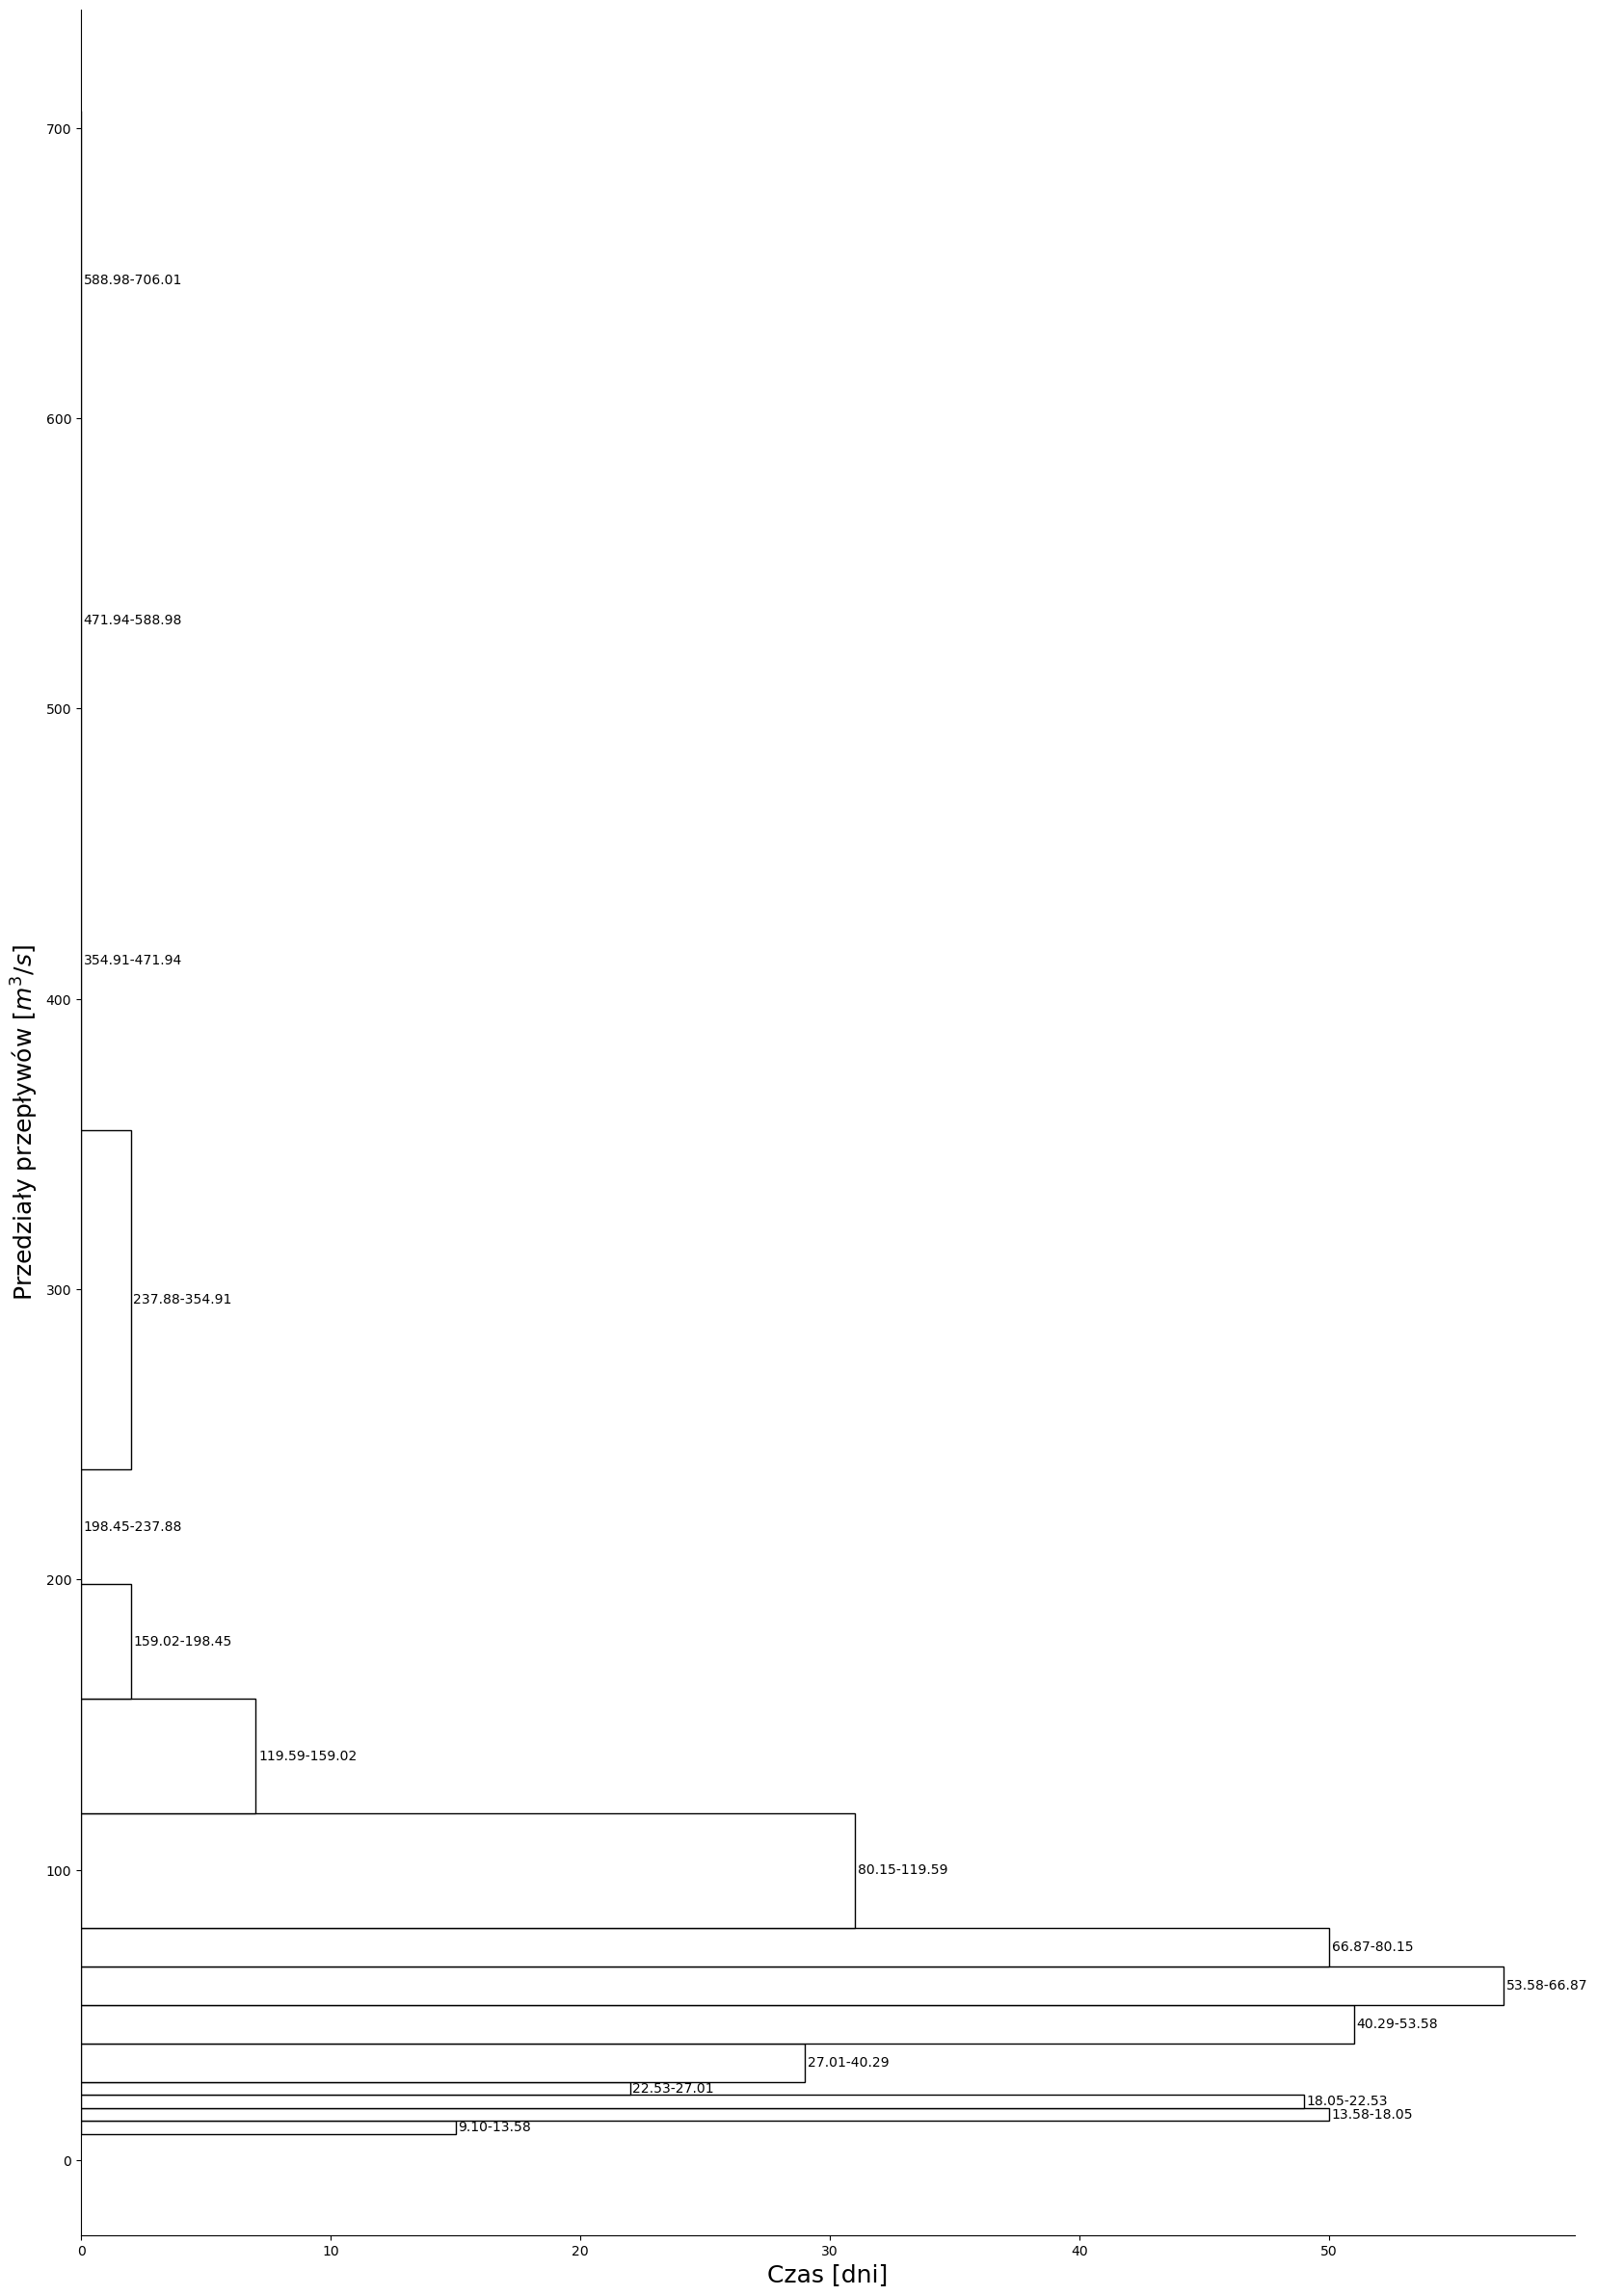

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some random data
# Q = np.random.normal(size=1000)

# Compute the bins
Qmin = Q.min()
Qmax = Q.max()

dQ = np.log(Qmax) - np.log(Qmin)

Qb = np.array([Qmin*0.99999, Qmin*np.exp(0.25*dQ), Qmin*np.exp(0.5*dQ), Qmin*np.exp(0.75*dQ), Qmax*1.00001])
diffQ = np.diff(Qb)
ddQ = diffQ/4

L = []
for i,ddq in enumerate(ddQ):
    L.append(np.round(np.arange(Qb[i],Qb[i+1]+0.0001,ddq),3))

Q_bins = np.unique(np.concatenate(L))
Q_bins.sort()

# Plot the histogram with no edge on the right side
fig, ax = plt.subplots(figsize=(20, 30))
ax.hist(Q1, bins=Q_bins, orientation='horizontal', edgecolor='black', facecolor='white')
ax.set_ylabel('Przedziały przepływów [$m^3/s$]',fontsize=18)
ax.set_xlabel('Czas [dni]',fontsize=18)
# ax.set_title('Histogram')

# Remove the right and top spines of the histogram frame
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add labels to the histogram bars
for i in range(len(Q_bins)-1):
    x = ax.patches[i].get_x() + ax.patches[i].get_width() + 0.1
    y = ax.patches[i].get_y() + ax.patches[i].get_height()/2
    label = f"{Q_bins[i]:.2f}-{Q_bins[i+1]:.2f}"
    ax.text(x, y, label, ha='left', va='center')

# Show the plot
plt.show()
